<a href="https://www.kaggle.com/code/sonawanelalitsunil/ai-assistants-in-student-life-ml-48-1?scriptVersionId=249901542" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-assistant-usage-in-student-life-synthetic/ai_assistant_usage_student_life.csv


## Title:
AI Assistants in Student Life

## Description:
AI assistants are transforming student life by offering personalized academic support, time management tools, and mental health assistance. From helping with homework, summarizing lectures, and translating texts to scheduling study plans and setting reminders, these digital companions improve learning efficiency and reduce stress. They also support students with disabilities through voice commands and real-time transcription. By integrating AI tools like ChatGPT, Google Assistant, and educational chatbots, students can enhance their productivity, access instant help, and focus more on critical thinking and creativity.











## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/ai-assistant-usage-in-student-life-synthetic/ai_assistant_usage_student_life.csv')

In [3]:
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [4]:
df.tail()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3
9999,SESSION10000,Undergraduate,Math,2025-04-16,10.85,3,Writing,4,Assignment Completed,True,4.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


In [6]:
df.describe()

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.846467,5.607500,3.479500,3.417780
std,13.897302,4.648764,0.991805,1.143331
min,0.030000,1.000000,1.000000,1.000000
25%,9.630000,2.000000,3.000000,2.600000
50%,16.650000,4.000000,4.000000,3.500000
75%,26.670000,8.000000,4.000000,4.400000
max,110.810000,39.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

SessionID              object
StudentLevel           object
Discipline             object
SessionDate            object
SessionLengthMin      float64
TotalPrompts            int64
TaskType               object
AI_AssistanceLevel      int64
FinalOutcome           object
UsedAgain                bool
SatisfactionRating    float64
dtype: object

In [10]:
df.shape

(10000, 11)

In [11]:
df.columns

Index(['SessionID', 'StudentLevel', 'Discipline', 'SessionDate',
       'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel',
       'FinalOutcome', 'UsedAgain', 'SatisfactionRating'],
      dtype='object')

## Data visaulizations

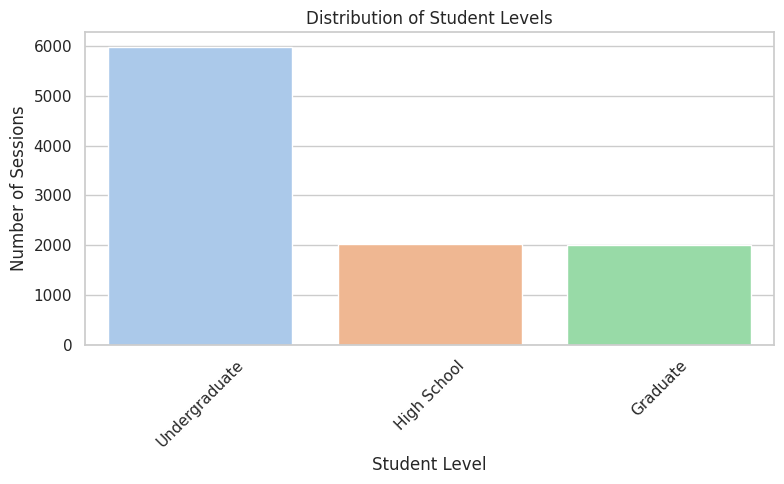

In [12]:
# Set Seaborn style
sns.set(style='whitegrid', palette='pastel')

# 1. Distribution of Student Levels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='StudentLevel', order=df['StudentLevel'].value_counts().index)
plt.title('Distribution of Student Levels')
plt.xlabel('Student Level')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

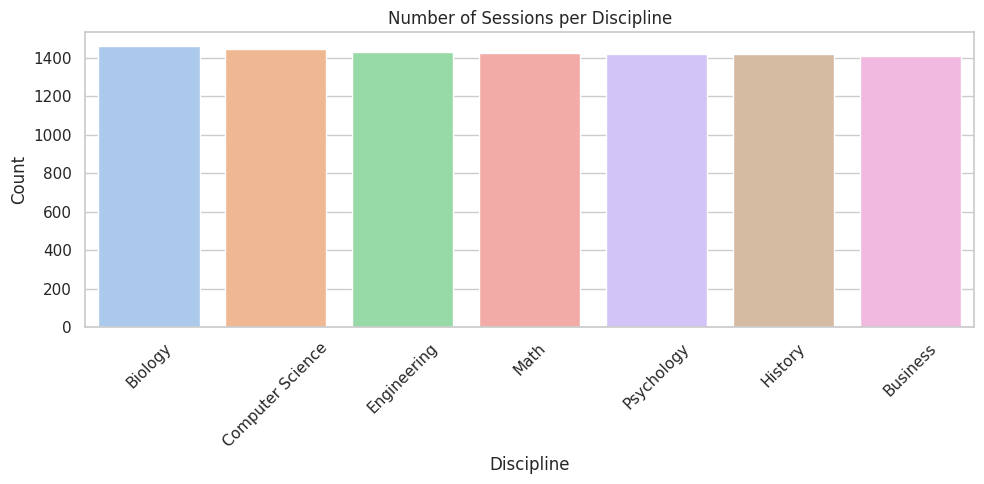

In [13]:
# 2. Sessions by Discipline
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Discipline', order=df['Discipline'].value_counts().index)
plt.title('Number of Sessions per Discipline')
plt.xlabel('Discipline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

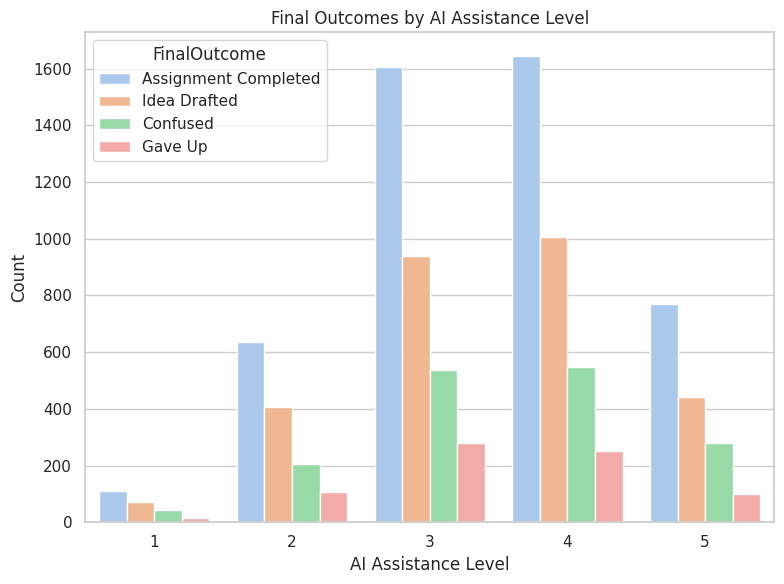

In [14]:
# 3. AI Assistance Level vs Final Outcome
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='AI_AssistanceLevel', hue='FinalOutcome')
plt.title('Final Outcomes by AI Assistance Level')
plt.xlabel('AI Assistance Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

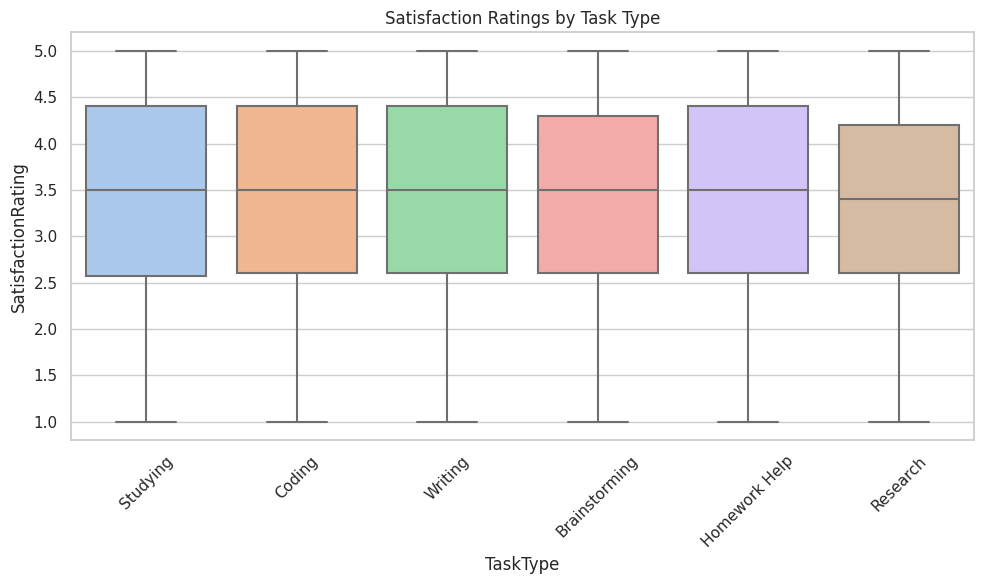

In [15]:
# 4. TaskType vs Satisfaction Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='TaskType', y='SatisfactionRating')
plt.title('Satisfaction Ratings by Task Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

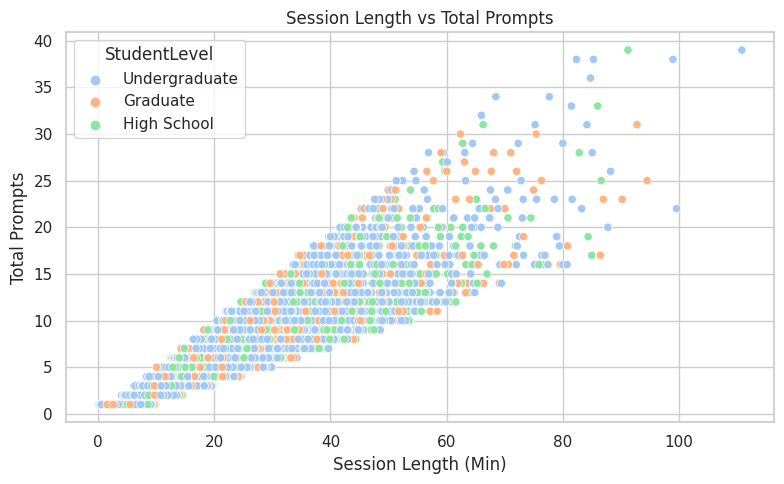

In [16]:
# 5. Session Length vs Total Prompts (Scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SessionLengthMin', y='TotalPrompts', hue='StudentLevel')
plt.title('Session Length vs Total Prompts')
plt.xlabel('Session Length (Min)')
plt.ylabel('Total Prompts')
plt.tight_layout()
plt.show()

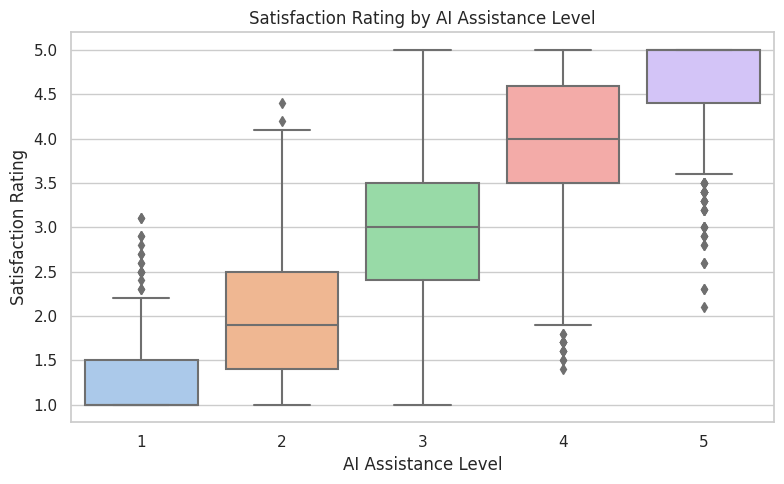

In [17]:
# 6. AI Assistance Level vs Satisfaction Rating
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='AI_AssistanceLevel', y='SatisfactionRating')
plt.title('Satisfaction Rating by AI Assistance Level')
plt.xlabel('AI Assistance Level')
plt.ylabel('Satisfaction Rating')
plt.tight_layout()
plt.show()

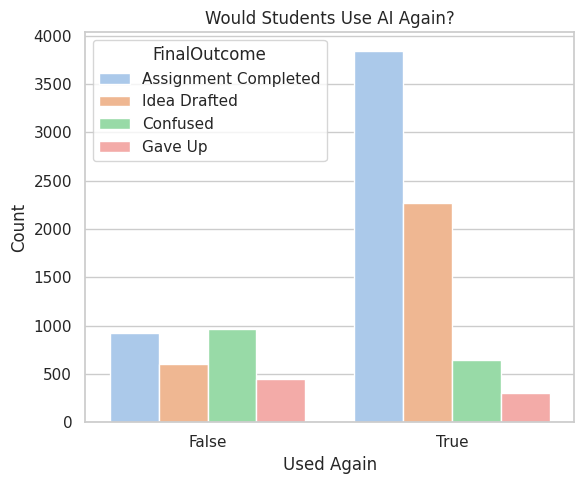

In [18]:
# 7. Usage Again Decision
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='UsedAgain', hue='FinalOutcome')
plt.title('Would Students Use AI Again?')
plt.xlabel('Used Again')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

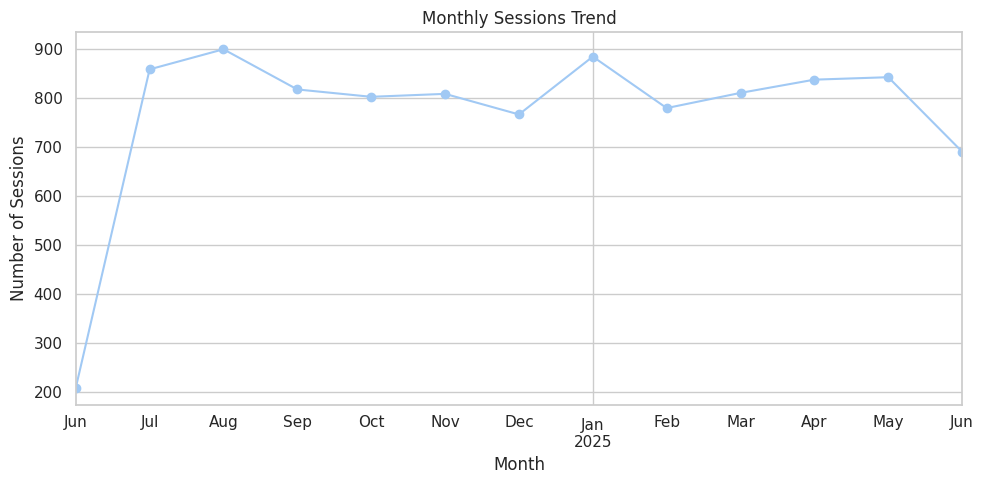

In [19]:
# 8. Trend of Sessions Over Time
df['SessionDate'] = pd.to_datetime(df['SessionDate'])
sessions_over_time = df.groupby(df['SessionDate'].dt.to_period('M')).size()
sessions_over_time.plot(kind='line', marker='o', figsize=(10, 5), title='Monthly Sessions Trend')
plt.xlabel('Month')
plt.ylabel('Number of Sessions')
plt.tight_layout()
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# Drop SessionID (non-informative) and parse dates
df.drop('SessionID', axis=1, inplace=True)
df['SessionDate'] = pd.to_datetime(df['SessionDate'])
df['SessionMonth'] = df['SessionDate'].dt.month
df['SessionWeekday'] = df['SessionDate'].dt.weekday
df.drop('SessionDate', axis=1, inplace=True)


In [22]:
# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df.drop('FinalOutcome', axis=1)
y = df['FinalOutcome']

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}


In [24]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc * 100  # convert to percentage


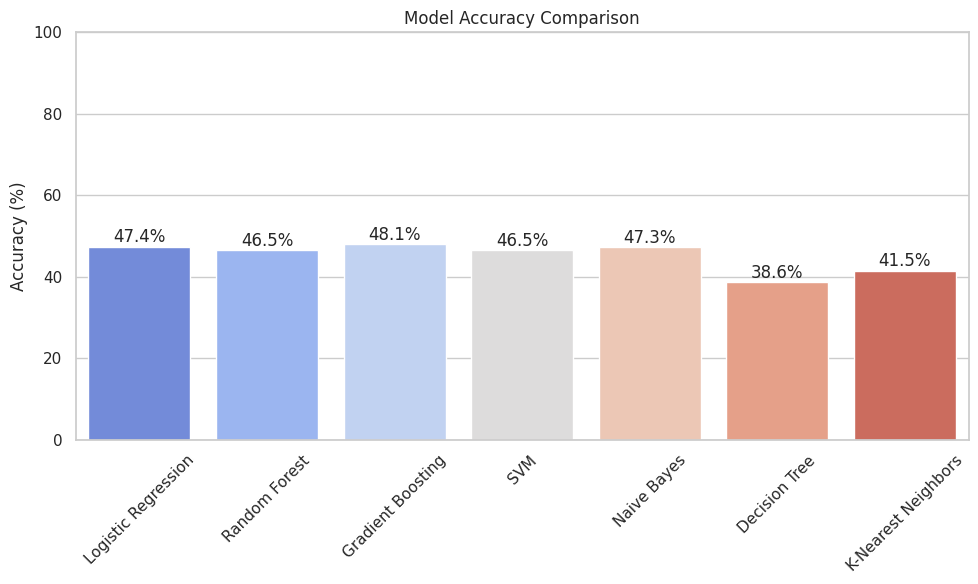

In [25]:
# Plot results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(results.values()):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

## Thank you ...pls upvote!!!